In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('final_taxi_data.csv')

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

Rows    : 697,821
Columns : 37


In [ ]:
before = len(df)
df = df.dropna(how='all')
print(f"\n✅ Blank rows removed : {before - len(df):,}")


✅ Blank rows removed : 0


In [ ]:
missing_cols = [
    'time_of_day',
    'is_peak_hour',
    'is_weekend',
    'fare_per_mile',
    'tip_percentage'
]

print(f"\nLast row values before fix:")
for col in missing_cols:
    print(f"   {col} → {df[col].iloc[-1]}")


Last row values before fix:
   time_of_day → nan
   is_peak_hour → nan
   is_weekend → nan
   fare_per_mile → nan
   tip_percentage → nan


In [ ]:
last_hour = df['pickup_hour'].iloc[-1]
if 6 <= last_hour < 12:
    df.loc[df.index[-1], 'time_of_day'] = 'Morning'
elif 12 <= last_hour < 17:
    df.loc[df.index[-1], 'time_of_day'] = 'Afternoon'
elif 17 <= last_hour < 21:
    df.loc[df.index[-1], 'time_of_day'] = 'Evening'
else:
    df.loc[df.index[-1], 'time_of_day'] = 'Night'

# is_peak_hour → based on pickup_hour
df.loc[df.index[-1], 'is_peak_hour'] = (
    1 if (7 <= last_hour <= 9) or
         (17 <= last_hour <= 19)
    else 0
)

In [ ]:
df.loc[df.index[-1], 'is_peak_hour'] = (
    1 if (7 <= last_hour <= 9) or
         (17 <= last_hour <= 19)
    else 0
)

# is_weekend → based on pickup_day
last_day = df['pickup_day'].iloc[-1]
df.loc[df.index[-1], 'is_weekend'] = (
    1 if last_day in ['Saturday', 'Sunday']
    else 0
)

In [ ]:
last_fare = df['fare_amount'].iloc[-1]
last_dist = df['trip_distance'].iloc[-1]
df.loc[df.index[-1], 'fare_per_mile'] = round(
    last_fare / last_dist, 2
) if last_dist > 0 else 0

In [ ]:
last_tip = df['tip_amount'].iloc[-1]
df.loc[df.index[-1], 'tip_percentage'] = round(
    (last_tip / last_fare) * 100, 2
) if last_fare > 0 else 0

print(f"\nLast row values after fix:")
for col in missing_cols:
    print(f"   {col} → {df[col].iloc[-1]}")


Last row values after fix:
   time_of_day → Afternoon
   is_peak_hour → 0.0
   is_weekend → 0.0
   fare_per_mile → 7.07
   tip_percentage → 0.0


In [ ]:
df = df.reset_index(drop=True)

In [ ]:
print("\n" + "="*50)
print("FINAL CHECK")
print("="*50)
print(f"Total rows     : {len(df):,}")
print(f"Total columns  : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("✅ Zero missing values!")
else:
    print("Remaining missing:")
    print(df.isnull().sum()[df.isnull().sum() > 0])


FINAL CHECK
Total rows     : 697,821
Total columns  : 37
Missing values : 0
✅ Zero missing values!


In [ ]:
from google.colab import files
files.download('final_taxi_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Always keep import at top of cell
from google.colab import files

df.to_csv('final_taxi_data.csv', index=False)
files.download('final_taxi_data.csv')

print("\n✅ Fixed file downloaded!")
print(f"✅ Final shape : {df.shape}")

NameError: name 'df' is not defined


STEP 1 — EDA OVERVIEW


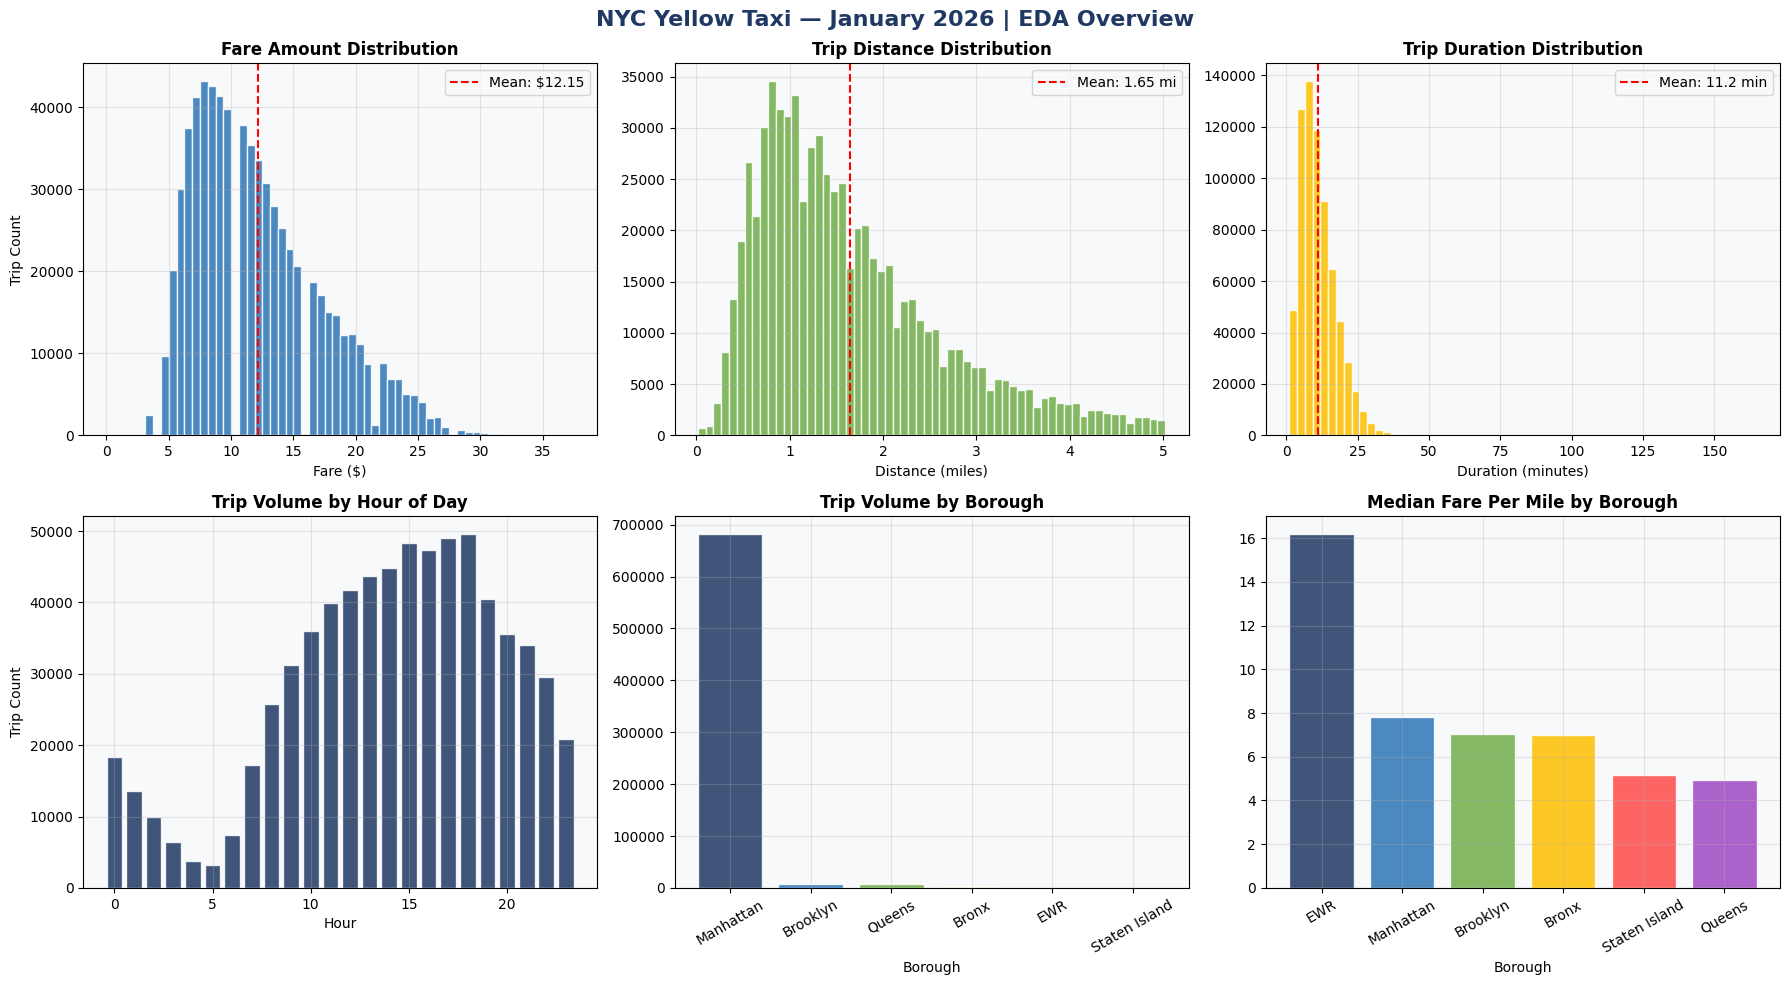

✅ Saved: eda_overview.png

EDA Key Stats:
   Mean fare     : $12.15
   Mean distance : 1.65 miles
   Mean duration : 11.2 mins
   Peak hour     : 18:00

Borough distribution:
PU_Borough
Manhattan        682601
Brooklyn           7015
Queens             6936
Bronx              1265
EWR                   2
Staten Island         2

STEP 2 — TEMPORAL PATTERNS


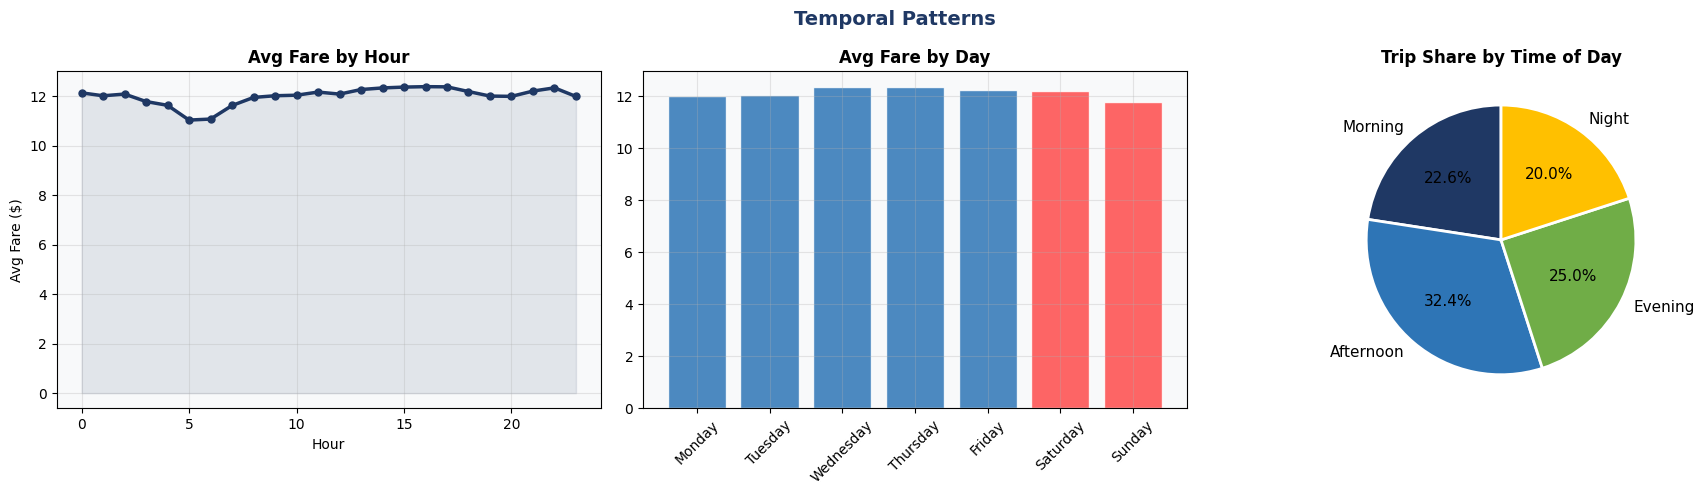

✅ Saved: temporal_patterns.png

Temporal Key Stats:
   Highest fare hour : 16:00 ($12.39)
   Lowest fare hour  : 5:00 ($11.04)
   Highest fare day  : Wednesday
   Lowest fare day   : Sunday

STEP 3 — FAIRNESS PREVIEW


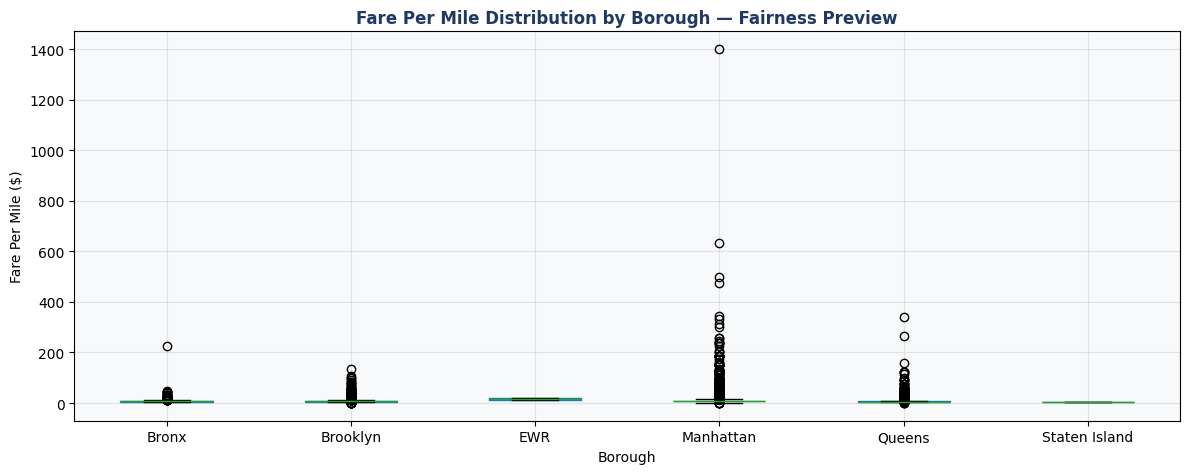


Fare Per Mile Stats by Borough:
                mean  median   std
PU_Borough                        
Bronx           8.33    6.98  7.36
Brooklyn        8.41    7.03  5.64
EWR            16.20   16.20  7.24
Manhattan       8.61    7.81  4.49
Queens          6.32    4.93  7.90
Staten Island   5.16    5.16  0.95

✅ Saved: fairness_preview_borough.png

STEP 4 — FAIR FARE REGRESSION MODEL
Training rows : 558,256
Testing rows  : 139,565

⏳ Training model... please wait...

✅ Model Complete!
   RMSE : $0.63
   MAE  : $0.37
   R²   : 0.9855

Fairness Residual Summary:
count    697821.000
mean          0.003
std           0.350
min         -18.952
25%          -0.105
50%           0.000
75%           0.119
max          20.484
Name: fairness_residual, dtype: float64


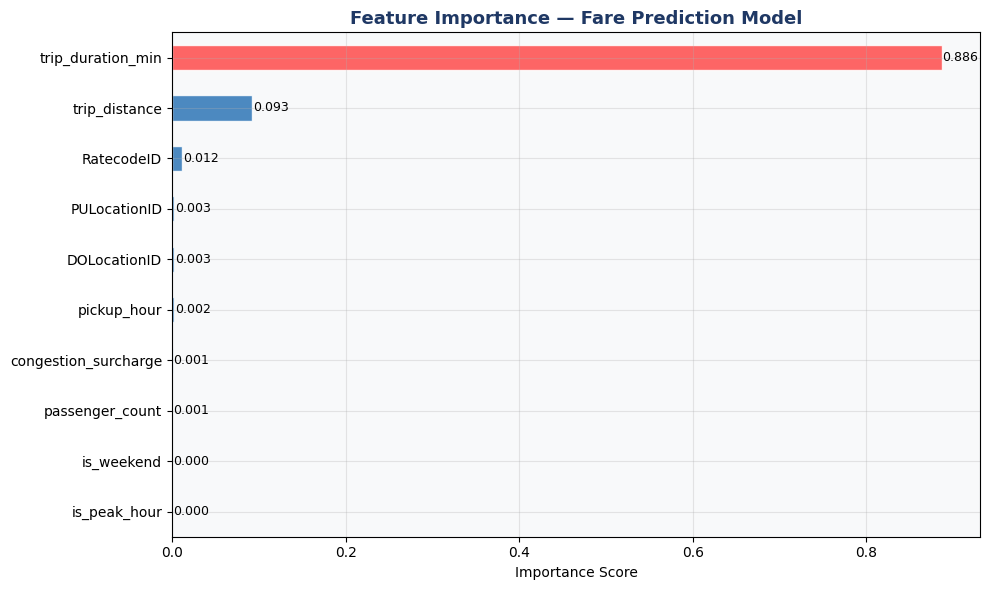

✅ Saved: feature_importance.png

STEP 5 — ZONE LEVEL FAIRNESS ANALYSIS

Top 10 Overpriced Zones:
                         PU_Zone PU_Borough  mean_residual  trip_count
70             East Williamsburg   Brooklyn       0.220185         130
167                     Red Hook   Brooklyn       0.214826          65
68                  East Tremont      Bronx       0.165996          50
56            DUMBO/Vinegar Hill   Brooklyn       0.154475         284
223                     Woodside     Queens       0.153984          86
189                     Steinway     Queens       0.143801          67
55   Downtown Brooklyn/MetroTech   Brooklyn       0.143791         276
107              Jackson Heights     Queens       0.140551          67
60                 East Elmhurst     Queens       0.137960         127
72                      Elmhurst     Queens       0.128396          56

Top 10 Underpriced Zones:
                               PU_Zone PU_Borough  mean_residual  trip_count
20                

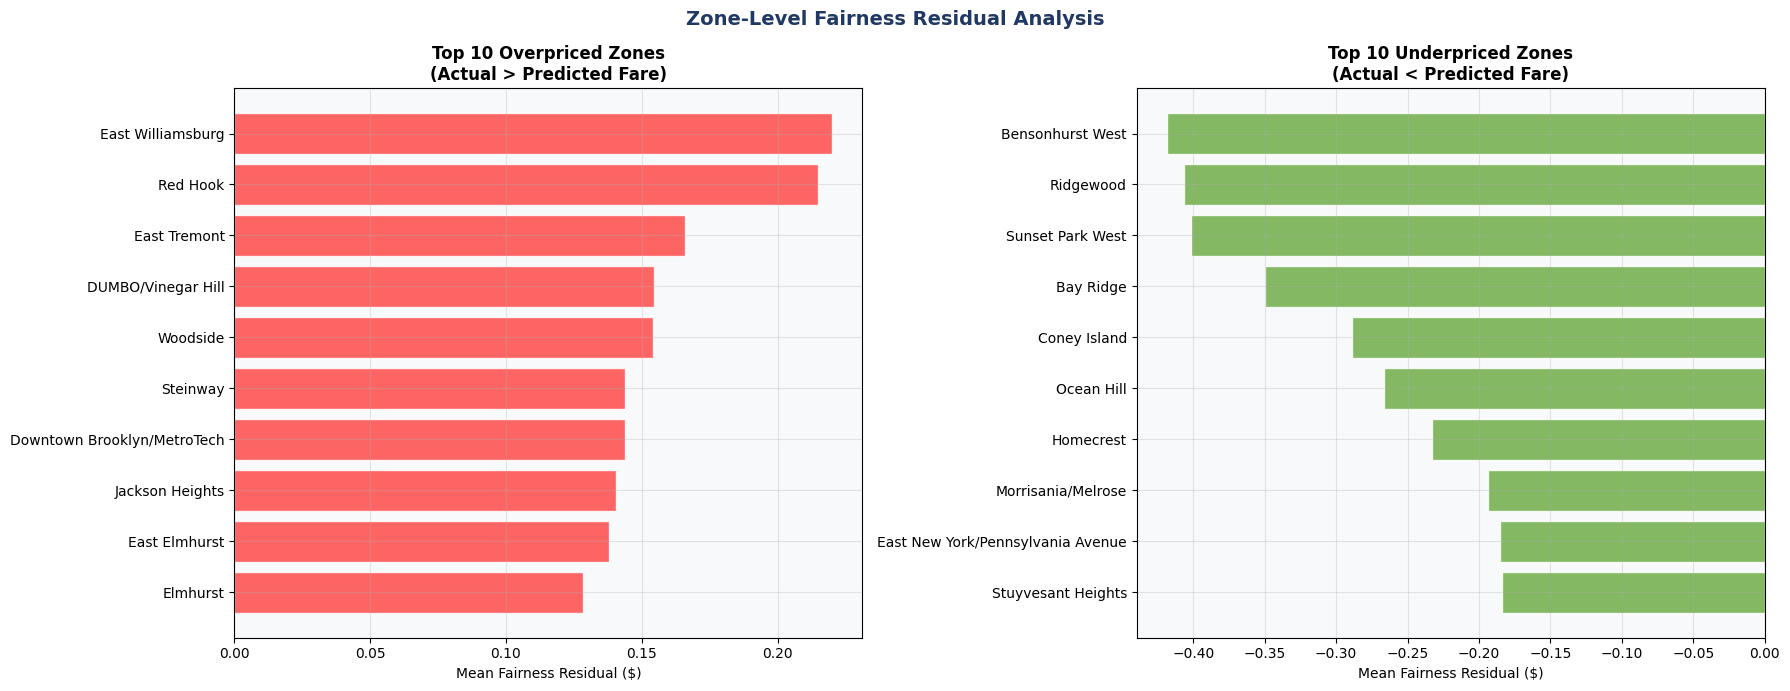


Borough Level Fairness Summary:
                 mean  median     std
PU_Borough                           
Bronx           0.095  -0.020   1.239
Brooklyn       -0.026  -0.050   0.988
EWR            10.368  10.368  14.306
Manhattan       0.003   0.000   0.327
Queens          0.017   0.000   0.694
Staten Island   0.014   0.014   0.020

✅ Saved: zone_fairness_residuals.png

STEP 6 — K-MEANS ZONE CLUSTERING

Cluster Summary:
         trip_count  mean_fare  mean_residual  mean_fare_per_mile
cluster                                                          
0           1587.62      15.14           0.05                7.65
1            100.35      20.72          -0.23                8.22
2          18970.12      11.89          -0.00                8.61
3            189.93      20.03          -0.02                9.13

Cluster Borough Composition:
PU_Borough  Bronx  Brooklyn  Manhattan  Queens
cluster                                       
0               2        12         25      13
1     

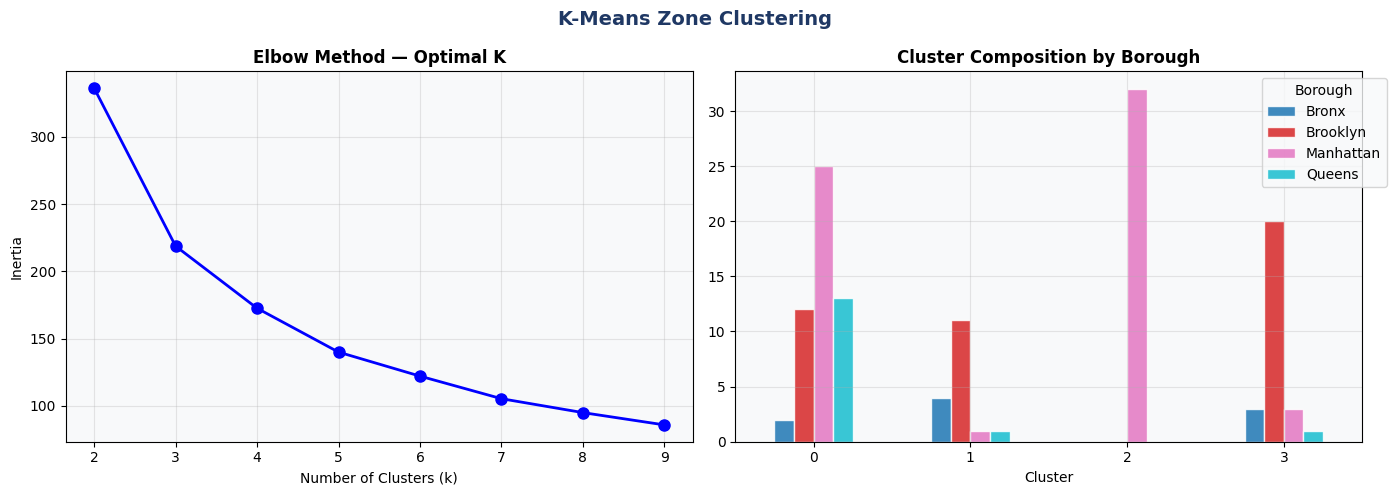

✅ Saved: kmeans_clusters.png

STEP 7 — ANOMALY DETECTION

✅ Anomaly Detection Complete!
   Total trips  : 697,821
   Anomalies    : 34,891
   Rate         : 5.0%

Anomaly vs Normal Comparison:
                   Normal  Anomaly
fare_amount         11.77    19.37
trip_distance        1.60     2.65
trip_duration_min   10.71    20.49
speed_mph            9.35     9.38
fare_per_mile        8.34    13.25
tip_percentage      23.28    17.12
total_amount        19.53    26.54

Anomaly Rate by Borough (%):
PU_Borough
Staten Island    50.00
EWR              50.00
Bronx            43.87
Queens           41.13
Brooklyn         32.64
Manhattan         4.28
dtype: float64


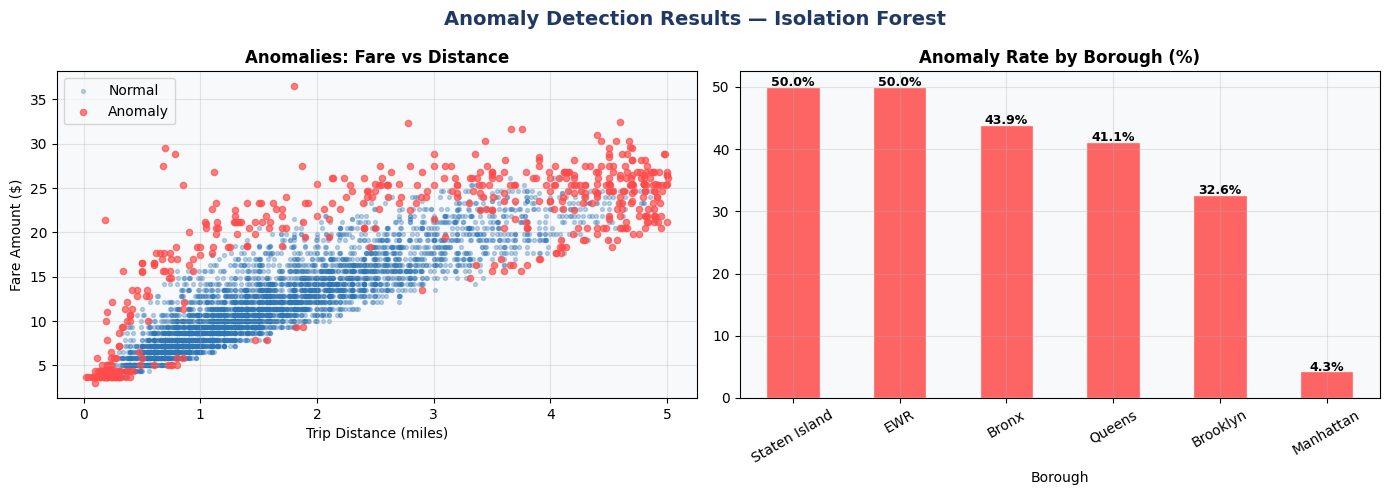

✅ Saved: anomaly_detection.png

STEP 8 — SERVICE DISTRIBUTION
Total zones       : 227
Underserved zones : 55

Bottom 10 zones by trip count:
                              PU_Zone     PU_Borough  trip_count
3                       Arden Heights  Staten Island           1
4             Arrochar/Fort Wadsworth  Staten Island           1
6                        Astoria Park         Queens           1
7                          Auburndale         Queens           1
87                      Fresh Meadows         Queens           1
98                    Hammels/Arverne         Queens           1
151                   Oakland Gardens         Queens           1
166                   Randalls Island      Manhattan           1
175  Saint Michaels Cemetery/Woodside         Queens           1
0                      Newark Airport            EWR           2

Tip Behaviour by Borough:
               mean_tip_pct  median_tip_pct  card_trip_share
PU_Borough                                              

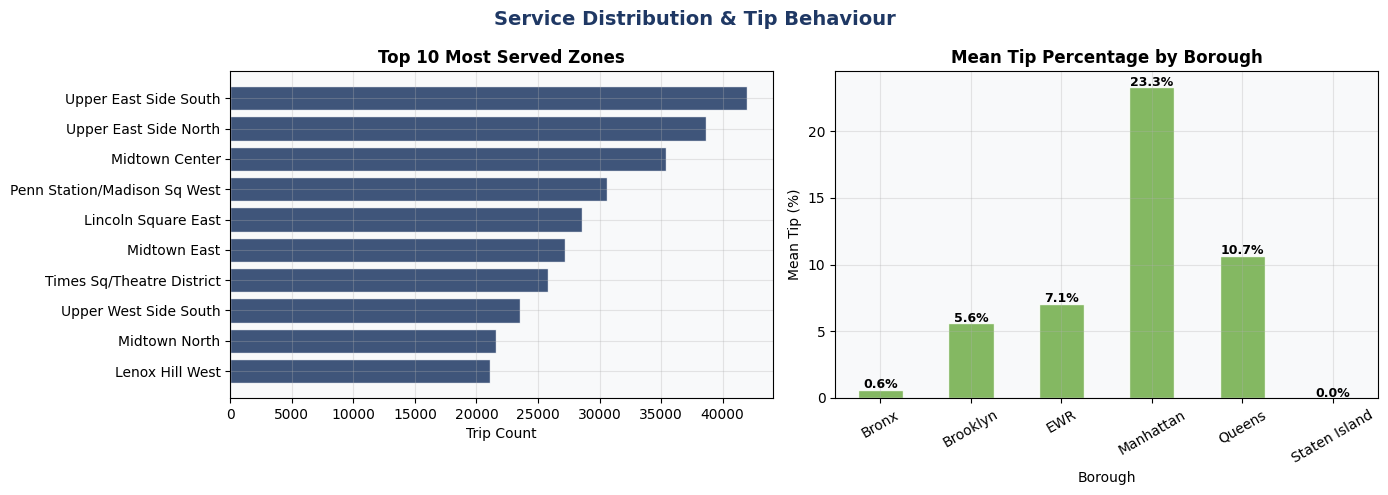

✅ Saved: service_distribution.png

FINAL AUDIT SUMMARY — KEY FINDINGS
Total trips analysed  : 697,821
Model R²              : 0.9855
Model RMSE            : $0.63
Model MAE             : $0.37
Anomalous trips       : 34,891 (5.0%)
Most overpriced zone  : East Williamsburg (Brooklyn)
Most underpriced zone : Bensonhurst West (Brooklyn)
Underserved zones     : 55
Peak demand hour      : 18:00
Top borough           : Manhattan

Fairness Residual by Borough:
                 mean  median     std
PU_Borough                           
Bronx           0.095  -0.020   1.239
Brooklyn       -0.026  -0.050   0.988
EWR            10.368  10.368  14.306
Manhattan       0.003   0.000   0.327
Queens          0.017   0.000   0.694
Staten Island   0.014   0.014   0.020

Tip Behaviour by Borough:
               mean_tip_pct  median_tip_pct  card_trip_share
PU_Borough                                                  
Bronx                  0.62            0.00            88.22
Brooklyn               5.63 

In [1]:
# ============================================
# NYC TAXI FAIRNESS AUDIT
# COMPLETE PIPELINE — STEP 1 TO STEP 9
# ============================================

# STEP 0 — Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import (RandomForestRegressor,
                               IsolationForest)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error,
                              mean_absolute_error,
                              r2_score)
from scipy import stats
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#f8f9fa',
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'font.family'    : 'DejaVu Sans'
})
COLORS = ['#1F3864','#2E75B6','#70AD47',
          '#FFC000','#FF4B4B','#9E48C2']

# Load taxi data
df = pd.read_csv('final_taxi_data (2).csv')

# ============================================
# STEP 1 — EDA OVERVIEW
# ============================================
print("\n" + "="*50)
print("STEP 1 — EDA OVERVIEW")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'NYC Yellow Taxi — January 2026 | EDA Overview',
    fontsize=16,
    fontweight='bold',
    color='#1F3864'
)

# 1a. Fare distribution
axes[0,0].hist(
    df['fare_amount'], bins=60,
    color=COLORS[1], edgecolor='white', alpha=0.85)
axes[0,0].set_title(
    'Fare Amount Distribution', fontweight='bold')
axes[0,0].set_xlabel('Fare ($)')
axes[0,0].set_ylabel('Trip Count')
axes[0,0].axvline(
    df['fare_amount'].mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Mean: ${df['fare_amount'].mean():.2f}")
axes[0,0].legend()

# 1b. Trip distance distribution
axes[0,1].hist(
    df['trip_distance'], bins=60,
    color=COLORS[2], edgecolor='white', alpha=0.85)
axes[0,1].set_title(
    'Trip Distance Distribution', fontweight='bold')
axes[0,1].set_xlabel('Distance (miles)')
axes[0,1].axvline(
    df['trip_distance'].mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Mean: {df['trip_distance'].mean():.2f} mi")
axes[0,1].legend()

# 1c. Trip duration distribution
axes[0,2].hist(
    df['trip_duration_min'], bins=60,
    color=COLORS[3], edgecolor='white', alpha=0.85)
axes[0,2].set_title(
    'Trip Duration Distribution', fontweight='bold')
axes[0,2].set_xlabel('Duration (minutes)')
axes[0,2].axvline(
    df['trip_duration_min'].mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Mean: {df['trip_duration_min'].mean():.1f} min")
axes[0,2].legend()

# 1d. Hourly trip volume
hourly = df.groupby('pickup_hour').size().reset_index(
    name='count')
axes[1,0].bar(
    hourly['pickup_hour'], hourly['count'],
    color=COLORS[0], alpha=0.85, edgecolor='white')
axes[1,0].set_title(
    'Trip Volume by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Trip Count')

peak_hour = hourly.loc[
    hourly['count'].idxmax(), 'pickup_hour']

# 1e. Trips by borough
borough_counts = df['PU_Borough'].value_counts()
axes[1,1].bar(
    borough_counts.index, borough_counts.values,
    color=COLORS[:len(borough_counts)],
    alpha=0.85, edgecolor='white')
axes[1,1].set_title(
    'Trip Volume by Borough', fontweight='bold')
axes[1,1].set_xlabel('Borough')
axes[1,1].tick_params(axis='x', rotation=30)

# 1f. Fare per mile by borough
borough_fpm = df.groupby('PU_Borough')[
    'fare_per_mile'
].median().sort_values(ascending=False)
axes[1,2].bar(
    borough_fpm.index, borough_fpm.values,
    color=COLORS[:len(borough_fpm)],
    alpha=0.85, edgecolor='white')
axes[1,2].set_title(
    'Median Fare Per Mile by Borough',
    fontweight='bold')
axes[1,2].set_xlabel('Borough')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_overview.png")

print(f"\nEDA Key Stats:")
print(f"   Mean fare     : ${df['fare_amount'].mean():.2f}")
print(f"   Mean distance : {df['trip_distance'].mean():.2f} miles")
print(f"   Mean duration : {df['trip_duration_min'].mean():.1f} mins")
print(f"   Peak hour     : {peak_hour}:00")
print(f"\nBorough distribution:")
print(borough_counts.to_string())

# ============================================
# STEP 2 — TEMPORAL PATTERNS
# ============================================
print("\n" + "="*50)
print("STEP 2 — TEMPORAL PATTERNS")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Temporal Patterns',
    fontsize=14, fontweight='bold', color='#1F3864')

# 2a. Hourly fare
hourly_fare = df.groupby(
    'pickup_hour')['fare_amount'].mean()
axes[0].plot(
    hourly_fare.index, hourly_fare.values,
    color=COLORS[0], linewidth=2.5,
    marker='o', markersize=5)
axes[0].fill_between(
    hourly_fare.index, hourly_fare.values,
    alpha=0.1, color=COLORS[0])
axes[0].set_title('Avg Fare by Hour', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Fare ($)')

# 2b. By day of week
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_fare = df.groupby('pickup_day')[
    'fare_amount'].mean().reindex(day_order)
bar_colors = [
    '#FF4B4B' if d in ['Saturday','Sunday']
    else COLORS[1] for d in day_order
]
axes[1].bar(
    day_fare.index, day_fare.values,
    color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Avg Fare by Day', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# 2c. Time of day trip volume
tod_counts = df['time_of_day'].value_counts().reindex([
    'Morning','Afternoon','Evening','Night'])
axes[2].pie(
    tod_counts.values,
    labels=tod_counts.index,
    autopct='%1.1f%%',
    colors=COLORS[:4],
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title(
    'Trip Share by Time of Day', fontweight='bold')

plt.tight_layout()
plt.savefig('temporal_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: temporal_patterns.png")

print(f"\nTemporal Key Stats:")
print(f"   Highest fare hour : "
      f"{hourly_fare.idxmax()}:00 "
      f"(${hourly_fare.max():.2f})")
print(f"   Lowest fare hour  : "
      f"{hourly_fare.idxmin()}:00 "
      f"(${hourly_fare.min():.2f})")
print(f"   Highest fare day  : {day_fare.idxmax()}")
print(f"   Lowest fare day   : {day_fare.idxmin()}")

# ============================================
# STEP 3 — FAIRNESS PREVIEW
# ============================================
print("\n" + "="*50)
print("STEP 3 — FAIRNESS PREVIEW")
print("="*50)

fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(
    column='fare_per_mile',
    by='PU_Borough', ax=ax,
    patch_artist=True, notch=False)
ax.set_title(
    'Fare Per Mile Distribution by Borough'
    ' — Fairness Preview',
    fontweight='bold', color='#1F3864')
ax.set_xlabel('Borough')
ax.set_ylabel('Fare Per Mile ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fairness_preview_borough.png',
            dpi=150, bbox_inches='tight')
plt.show()

borough_fpm_stats = df.groupby('PU_Borough')[
    'fare_per_mile'
].agg(['mean','median','std']).round(2)
print(f"\nFare Per Mile Stats by Borough:")
print(borough_fpm_stats)
print("\n✅ Saved: fairness_preview_borough.png")

# ============================================
# STEP 4 — FAIR FARE REGRESSION MODEL
# ============================================
print("\n" + "="*50)
print("STEP 4 — FAIR FARE REGRESSION MODEL")
print("="*50)

features = [
    'trip_distance', 'trip_duration_min',
    'pickup_hour', 'is_peak_hour', 'is_weekend',
    'PULocationID', 'DOLocationID',
    'RatecodeID', 'passenger_count',
    'congestion_surcharge'
]

df_model = df[features + ['fare_amount']].dropna()
X = df_model[features]
y = df_model['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")
print(f"\n⏳ Training model... please wait...")

model = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\n✅ Model Complete!")
print(f"   RMSE : ${rmse:.2f}")
print(f"   MAE  : ${mae:.2f}")
print(f"   R²   : {r2:.4f}")

# Fairness residuals
df['predicted_fare'] = model.predict(
    df[features].fillna(0))
df['fairness_residual'] = (
    df['fare_amount'] - df['predicted_fare'])

print(f"\nFairness Residual Summary:")
print(df['fairness_residual'].describe().round(3))

# Feature importance plot
feat_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = [
    '#FF4B4B' if v == feat_importance.max()
    else COLORS[1]
    for v in feat_importance.values
]
feat_importance.plot(
    kind='barh', ax=ax,
    color=colors_fi, alpha=0.85, edgecolor='white')
ax.set_title(
    'Feature Importance — Fare Prediction Model',
    fontweight='bold', color='#1F3864', fontsize=13)
ax.set_xlabel('Importance Score')

for i, val in enumerate(feat_importance.values):
    ax.text(val + 0.001, i, f'{val:.3f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

# ============================================
# STEP 5 — ZONE LEVEL FAIRNESS ANALYSIS
# ============================================
print("\n" + "="*50)
print("STEP 5 — ZONE LEVEL FAIRNESS ANALYSIS")
print("="*50)

zone_fairness = df.groupby([
    'PULocationID','PU_Zone',
    'PU_Borough','PU_service_zone'
]).agg(
    trip_count        =('fare_amount','count'),
    mean_fare         =('fare_amount','mean'),
    mean_predicted    =('predicted_fare','mean'),
    mean_residual     =('fairness_residual','mean'),
    median_residual   =('fairness_residual','median'),
    mean_fare_per_mile=('fare_per_mile','mean')
).reset_index()

zone_fairness = zone_fairness[
    zone_fairness['trip_count'] >= 50]

top_overpriced  = zone_fairness.nlargest(
    10, 'mean_residual')
top_underpriced = zone_fairness.nsmallest(
    10, 'mean_residual')

print(f"\nTop 10 Overpriced Zones:")
print(top_overpriced[[
    'PU_Zone','PU_Borough',
    'mean_residual','trip_count'
]].to_string())

print(f"\nTop 10 Underpriced Zones:")
print(top_underpriced[[
    'PU_Zone','PU_Borough',
    'mean_residual','trip_count'
]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Zone-Level Fairness Residual Analysis',
    fontsize=14, fontweight='bold', color='#1F3864')

axes[0].barh(
    top_overpriced['PU_Zone'],
    top_overpriced['mean_residual'],
    color='#FF4B4B', alpha=0.85, edgecolor='white')
axes[0].set_title(
    'Top 10 Overpriced Zones\n'
    '(Actual > Predicted Fare)', fontweight='bold')
axes[0].set_xlabel('Mean Fairness Residual ($)')
axes[0].invert_yaxis()

axes[1].barh(
    top_underpriced['PU_Zone'],
    top_underpriced['mean_residual'],
    color='#70AD47', alpha=0.85, edgecolor='white')
axes[1].set_title(
    'Top 10 Underpriced Zones\n'
    '(Actual < Predicted Fare)', fontweight='bold')
axes[1].set_xlabel('Mean Fairness Residual ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('zone_fairness_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()

borough_fairness = df.groupby('PU_Borough')[
    'fairness_residual'
].agg(['mean','median','std']).round(3)
print(f"\nBorough Level Fairness Summary:")
print(borough_fairness)
print("\n✅ Saved: zone_fairness_residuals.png")

# ============================================
# STEP 6 — K-MEANS CLUSTERING
# ============================================
print("\n" + "="*50)
print("STEP 6 — K-MEANS ZONE CLUSTERING")
print("="*50)

cluster_features = [
    'trip_count', 'mean_fare',
    'mean_residual', 'mean_fare_per_mile'
]

X_cluster = zone_fairness[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(
        n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'K-Means Zone Clustering',
    fontsize=14, fontweight='bold', color='#1F3864')

axes[0].plot(
    K_range, inertias, 'bo-',
    linewidth=2, markersize=8)
axes[0].set_title(
    'Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Final k=4
km_final = KMeans(
    n_clusters=4, random_state=42, n_init=10)
zone_fairness['cluster'] = km_final.fit_predict(
    X_scaled)

cluster_summary = zone_fairness.groupby('cluster')[
    cluster_features].mean().round(2)
print(f"\nCluster Summary:")
print(cluster_summary)

cluster_borough = zone_fairness.groupby([
    'cluster','PU_Borough'
]).size().unstack(fill_value=0)
print(f"\nCluster Borough Composition:")
print(cluster_borough)

cluster_borough.plot(
    kind='bar', ax=axes[1],
    colormap='tab10', alpha=0.85, edgecolor='white')
axes[1].set_title(
    'Cluster Composition by Borough',
    fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(
    title='Borough', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('kmeans_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: kmeans_clusters.png")

# ============================================
# STEP 7 — ANOMALY DETECTION
# ============================================
print("\n" + "="*50)
print("STEP 7 — ANOMALY DETECTION")
print("="*50)

anomaly_features = [
    'fare_amount', 'trip_distance',
    'trip_duration_min', 'speed_mph',
    'fare_per_mile', 'tip_percentage',
    'total_amount'
]

df_anomaly = df[anomaly_features].dropna()
iso = IsolationForest(
    contamination=0.05, random_state=42, n_jobs=-1)
df.loc[df_anomaly.index, 'anomaly'] = (
    iso.fit_predict(df_anomaly))

anomaly_count = (df['anomaly'] == -1).sum()
total         = df['anomaly'].notna().sum()

print(f"\n✅ Anomaly Detection Complete!")
print(f"   Total trips  : {total:,}")
print(f"   Anomalies    : {anomaly_count:,}")
print(f"   Rate         : "
      f"{anomaly_count/total*100:.1f}%")

anomalies  = df[df['anomaly'] == -1]
normal     = df[df['anomaly'] ==  1]

comparison = pd.DataFrame({
    'Normal'  : normal[anomaly_features].mean(),
    'Anomaly' : anomalies[anomaly_features].mean()
}).round(2)
print(f"\nAnomaly vs Normal Comparison:")
print(comparison)

borough_anomaly = df.groupby('PU_Borough').apply(
    lambda x: (x['anomaly'] == -1).sum() /
    len(x) * 100
).round(2).sort_values(ascending=False)
print(f"\nAnomaly Rate by Borough (%):")
print(borough_anomaly)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Anomaly Detection Results — Isolation Forest',
    fontsize=14, fontweight='bold', color='#1F3864')

axes[0].scatter(
    normal['trip_distance'].sample(
        5000, random_state=42),
    normal['fare_amount'].sample(
        5000, random_state=42),
    alpha=0.3, color=COLORS[1], s=8, label='Normal')
axes[0].scatter(
    anomalies['trip_distance'].sample(
        min(500, len(anomalies)), random_state=42),
    anomalies['fare_amount'].sample(
        min(500, len(anomalies)), random_state=42),
    alpha=0.7, color='#FF4B4B', s=20, label='Anomaly')
axes[0].set_title(
    'Anomalies: Fare vs Distance', fontweight='bold')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Fare Amount ($)')
axes[0].legend()

borough_anomaly.plot(
    kind='bar', ax=axes[1],
    color=COLORS[4], alpha=0.85, edgecolor='white')
axes[1].set_title(
    'Anomaly Rate by Borough (%)', fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].tick_params(axis='x', rotation=30)

for i, val in enumerate(borough_anomaly.values):
    axes[1].text(
        i, val + 0.1, f'{val:.1f}%',
        ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('anomaly_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_detection.png")

# ============================================
# STEP 8 — SERVICE DISTRIBUTION
# ============================================
print("\n" + "="*50)
print("STEP 8 — SERVICE DISTRIBUTION")
print("="*50)

trips_per_zone = df.groupby([
    'PULocationID','PU_Zone','PU_Borough'
]).size().reset_index(name='trip_count')

underserved = trips_per_zone[
    trips_per_zone['trip_count'] <
    trips_per_zone['trip_count'].quantile(0.25)]

print(f"Total zones       : {len(trips_per_zone)}")
print(f"Underserved zones : {len(underserved)}")
print(f"\nBottom 10 zones by trip count:")
print(trips_per_zone.nsmallest(10,'trip_count')[[
    'PU_Zone','PU_Borough','trip_count'
]].to_string())

tip_analysis = df.groupby('PU_Borough').agg(
    mean_tip_pct   =('tip_percentage','mean'),
    median_tip_pct =('tip_percentage','median'),
    card_trip_share=('payment_type',
                     lambda x: (x==1).mean()*100)
).round(2)
print(f"\nTip Behaviour by Borough:")
print(tip_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Service Distribution & Tip Behaviour',
    fontsize=14, fontweight='bold', color='#1F3864')

top_zones = trips_per_zone.nlargest(10,'trip_count')
axes[0].barh(
    top_zones['PU_Zone'], top_zones['trip_count'],
    color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_title(
    'Top 10 Most Served Zones', fontweight='bold')
axes[0].set_xlabel('Trip Count')
axes[0].invert_yaxis()

tip_analysis['mean_tip_pct'].plot(
    kind='bar', ax=axes[1],
    color=COLORS[2], alpha=0.85, edgecolor='white')
axes[1].set_title(
    'Mean Tip Percentage by Borough',
    fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Mean Tip (%)')
axes[1].tick_params(axis='x', rotation=30)

for i, val in enumerate(
        tip_analysis['mean_tip_pct'].values):
    axes[1].text(
        i, val + 0.1, f'{val:.1f}%',
        ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('service_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: service_distribution.png")

# ============================================
# STEP 9 — FINAL AUDIT SUMMARY
# ============================================
print("\n" + "="*60)
print("FINAL AUDIT SUMMARY — KEY FINDINGS")
print("="*60)
print(f"Total trips analysed  : {len(df):,}")
print(f"Model R²              : {r2:.4f}")
print(f"Model RMSE            : ${rmse:.2f}")
print(f"Model MAE             : ${mae:.2f}")
print(f"Anomalous trips       : {anomaly_count:,} "
      f"({anomaly_count/total*100:.1f}%)")
print(f"Most overpriced zone  : "
      f"{top_overpriced.iloc[0]['PU_Zone']} "
      f"({top_overpriced.iloc[0]['PU_Borough']})")
print(f"Most underpriced zone : "
      f"{top_underpriced.iloc[0]['PU_Zone']} "
      f"({top_underpriced.iloc[0]['PU_Borough']})")
print(f"Underserved zones     : {len(underserved)}")
print(f"Peak demand hour      : {peak_hour}:00")
print(f"Top borough           : "
      f"{borough_counts.index[0]}")

print(f"\nFairness Residual by Borough:")
print(borough_fairness)

print(f"\nTip Behaviour by Borough:")
print(tip_analysis)

print(f"\nAnomaly Rate by Borough:")
print(borough_anomaly)

print(f"\nCluster Summary:")
print(cluster_summary)

print("\n" + "="*60)
print("ALL OUTPUT FILES SAVED ✅")
print("="*60)
print("  ✅ eda_overview.png")
print("  ✅ temporal_patterns.png")
print("  ✅ fairness_preview_borough.png")
print("  ✅ feature_importance.png")
print("  ✅ zone_fairness_residuals.png")
print("  ✅ kmeans_clusters.png")
print("  ✅ anomaly_detection.png")
print("  ✅ service_distribution.png")
print("\n  📄 All ready for conference paper!")

In [2]:
# ============================================
# ALL 4 FIXES — ADD AS NEW CELL
# Runs on existing df from your ipynb
# ============================================

import pandas as pd
import numpy as np
from sklearn.ensemble import (RandomForestRegressor,
                               RandomForestClassifier)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,
                              mean_squared_error,
                              mean_absolute_error,
                              classification_report,
                              confusion_matrix)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Install SMOTE if not already installed
import subprocess
subprocess.run(['pip', 'install',
    'imbalanced-learn', '-q'])

print("✅ Libraries loaded!")
print(f"✅ Using existing df: {df.shape}")
print(f"✅ Columns available: "
      f"{df.columns.tolist()}")

# ============================================
# FIX 1 — STRATIFIED SPLIT BY BOROUGH
# ============================================
print("\n" + "="*55)
print("FIX 1 — STRATIFIED SPLIT BY BOROUGH")
print("="*55)

features = [
    'trip_distance',
    'trip_duration_min',
    'pickup_hour',
    'is_peak_hour',
    'is_weekend',
    'PULocationID',
    'DOLocationID',
    'RatecodeID',
    'passenger_count',
    'congestion_surcharge'
]

df_model = df[features + [
    'fare_amount', 'PU_Borough'
]].dropna()

X = df_model[features]
y = df_model['fare_amount']

# Stratified split by borough
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df_model['PU_Borough']
)

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")
print(f"\n⏳ Training model... please wait...")

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\n✅ Fix 1 Complete!")
print(f"   R²   : {r2:.4f}")
print(f"   RMSE : ${rmse:.2f}")
print(f"   MAE  : ${mae:.2f}")

# Update fairness residuals
df['predicted_fare'] = model.predict(
    df[features].fillna(0))
df['fairness_residual'] = (
    df['fare_amount'] - df['predicted_fare'])

print(f"\nFairness Residual Summary:")
print(df['fairness_residual'].describe().round(3))

# ============================================
# FIX 2 — REMOVE EWR FROM FAIRNESS ANALYSIS
# ============================================
print("\n" + "="*55)
print("FIX 2 — REMOVE EWR FROM FAIRNESS")
print("="*55)

zone_fairness = df.groupby([
    'PULocationID',
    'PU_Zone',
    'PU_Borough',
    'PU_service_zone'
]).agg(
    trip_count        =('fare_amount','count'),
    mean_fare         =('fare_amount','mean'),
    mean_predicted    =('predicted_fare','mean'),
    mean_residual     =('fairness_residual','mean'),
    median_residual   =('fairness_residual','median'),
    mean_fare_per_mile=('fare_per_mile','mean')
).reset_index()

zone_fairness = zone_fairness[
    zone_fairness['trip_count'] >= 50]

# Remove EWR
before_ewr = len(zone_fairness)
zone_fairness = zone_fairness[
    zone_fairness['PU_Borough'] != 'EWR']

print(f"Zones before EWR : {before_ewr}")
print(f"Zones after EWR  : {len(zone_fairness)}")
print(f"EWR removed      : "
      f"{before_ewr - len(zone_fairness)}")

top_overpriced  = zone_fairness.nlargest(
    10, 'mean_residual')
top_underpriced = zone_fairness.nsmallest(
    10, 'mean_residual')

print(f"\n✅ Fix 2 Complete!")
print(f"\nTop 10 Overpriced Zones (EWR removed):")
print(top_overpriced[[
    'PU_Zone','PU_Borough',
    'mean_residual','trip_count'
]].to_string())

print(f"\nTop 10 Underpriced Zones:")
print(top_underpriced[[
    'PU_Zone','PU_Borough',
    'mean_residual','trip_count'
]].to_string())

borough_fairness = df.groupby('PU_Borough')[
    'fairness_residual'
].agg(['mean','median','std']).round(3)
print(f"\nBorough Fairness Summary:")
print(borough_fairness)

# ============================================
# FIX 3 — SMOTE CLASSIFICATION
# ============================================
print("\n" + "="*55)
print("FIX 3 — SMOTE CLASSIFICATION TASK")
print("="*55)

# Create binary class
df['is_overpriced'] = (
    df['fairness_residual'] > 0).astype(int)

print("Class distribution BEFORE SMOTE:")
print(df['is_overpriced'].value_counts())
print(f"Ratio: "
      f"{df['is_overpriced'].value_counts()[0]}"
      f" : "
      f"{df['is_overpriced'].value_counts()[1]}")

feat_clf = [
    'trip_distance',
    'trip_duration_min',
    'pickup_hour',
    'is_peak_hour',
    'is_weekend',
    'PULocationID',
    'DOLocationID',
    'RatecodeID',
    'congestion_surcharge'
]

X_clf = df[feat_clf].fillna(0)
y_clf = df['is_overpriced']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f"\nTraining set before SMOTE:")
print(y_tr.value_counts().to_dict())

# Apply SMOTE on training only
sm = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)

print(f"\nTraining set after SMOTE:")
print(pd.Series(y_tr_bal).value_counts().to_dict())

print(f"\n⏳ Training classifier... please wait...")
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_tr_bal, y_tr_bal)
y_pred_clf = clf.predict(X_te)

print("\n✅ Fix 3 Complete!")
print("\nClassification Report:")
print(classification_report(
    y_te, y_pred_clf,
    target_names=['Fair/Underpriced','Overpriced']
))

cm = confusion_matrix(y_te, y_pred_clf)
print("Confusion Matrix:")
print(cm)
print(f"\n   True Negatives  : {cm[0][0]:,}")
print(f"   False Positives : {cm[0][1]:,}")
print(f"   False Negatives : {cm[1][0]:,}")
print(f"   True Positives  : {cm[1][1]:,}")

# ============================================
# FIX 4 — BOROUGH LEVEL MODEL COMPARISON
# ============================================
print("\n" + "="*55)
print("FIX 4 — BOROUGH LEVEL MODEL PERFORMANCE")
print("="*55)

borough_results = {}

for borough in [
    'Manhattan','Brooklyn','Queens','Bronx'
]:
    df_b = df[
        df['PU_Borough'] == borough
    ][features + ['fare_amount']].dropna()

    if len(df_b) < 100:
        print(f"\n{borough}: insufficient data")
        continue

    X_b = df_b[features]
    y_b = df_b['fare_amount']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_b, y_b,
        test_size=0.2,
        random_state=42
    )

    print(f"\n⏳ Training {borough} model...")
    m = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_tr, y_tr)
    y_pred_b = m.predict(X_te)

    r2_b   = r2_score(y_te, y_pred_b)
    rmse_b = np.sqrt(
        mean_squared_error(y_te, y_pred_b))
    mae_b  = mean_absolute_error(y_te, y_pred_b)

    borough_results[borough] = {
        'n'   : len(df_b),
        'R2'  : round(r2_b, 4),
        'RMSE': round(rmse_b, 2),
        'MAE' : round(mae_b, 2)
    }

    print(f"✅ {borough} (n={len(df_b):,})")
    print(f"   R²   : {r2_b:.4f}")
    print(f"   RMSE : ${rmse_b:.2f}")
    print(f"   MAE  : ${mae_b:.2f}")

# Borough comparison summary table
print("\n" + "="*55)
print("BOROUGH COMPARISON SUMMARY TABLE")
print("="*55)
results_df = pd.DataFrame(borough_results).T
print(results_df.to_string())

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("ALL 4 FIXES COMPLETE — SUMMARY")
print("="*60)
print(f"Fix 1 — Stratified R²      : {r2:.4f}")
print(f"Fix 1 — Stratified RMSE    : ${rmse:.2f}")
print(f"Fix 2 — EWR zones removed  : "
      f"{before_ewr - len(zone_fairness)}")
print(f"Fix 3 — SMOTE balanced     : "
      f"{pd.Series(y_tr_bal).value_counts().to_dict()}")
print(f"Fix 4 — Boroughs compared  : "
      f"{list(borough_results.keys())}")
print(f"\nBorough Model Results:")
print(results_df.to_string())
print(f"\n✅ All fixes done!")
print(f"✅ Ready for conference paper!")

✅ Libraries loaded!
✅ Using existing df: (697821, 40)
✅ Columns available: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'trip_duration_min', 'speed_mph', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_date', 'time_of_day', 'is_peak_hour', 'is_weekend', 'fare_per_mile', 'tip_percentage', 'PU_Borough', 'PU_Zone', 'PU_service_zone', 'DO_Borough', 'DO_Zone', 'DO_service_zone', 'predicted_fare', 'fairness_residual', 'anomaly']

FIX 1 — STRATIFIED SPLIT BY BOROUGH
Training rows : 558,256
Testing rows  : 139,565

⏳ Training model... please wait...

✅ Fix 1 Complete!
   R²   : 0.9852
   RMSE : $0.63
   MAE  : $0.37

Fairness Residual Summary:
count    697821.000
mean          0.003
std    